In [ ]:

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image, ImageFile
from transformers import BertTokenizer, BertModel
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


TEXT_CKPT   = '/kaggle/input/datasets/yashmogha/dataset/text_best.pt'   
IMAGE_CKPT  = '/kaggle/input/datasets/yashmogha/dataset/Archive 2/image_best-2.pt'  
FUSION_CKPT = '/kaggle/input/datasets/yashmogha/dataset/fusion_best.pt' 

BATCH_TSV     = '/kaggle/input/datasets/yashmogha/dataset/multimodal_test_public.tsv'
BATCH_IMG_DIR = '/kaggle/input/datasets/yashmogha/dataset/test/test'
BATCH_SIZE    = 16  
SAVE_CSV      = '/kaggle/working/predictions.csv'

CFG = {
    'text_model':   'bert-base-uncased',
    'max_text_len': 128,  
    'image_size':   224,  
    'num_labels':   6,
    'out_dir':      '/kaggle/working',
    'class_names': [
        'true', 'satire/parody', 'misleading content',
        'imposter content', 'false connection', 'manipulated content',
    ]
}
os.makedirs(CFG['out_dir'], exist_ok=True)
print(' Configuration loaded.')

In [3]:

class TextModel(nn.Module):
    def __init__(self, num_labels=6, model_name='bert-base-uncased', dropout=0.3):
        super().__init__()
        self.bert      = BertModel.from_pretrained(model_name)
        self.embed_dim = self.bert.config.hidden_size
        self.drop      = nn.Dropout(dropout)
        self.head      = nn.Linear(self.embed_dim, num_labels)

    def get_embedding(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]   # [CLS]  (B, 768)

class ImageModel(nn.Module):
    def __init__(self, num_labels=6, dropout=0.3):
        super().__init__()
        backbone       = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2) # Matches 02IMAGEMODEL
        self.embed_dim = backbone.fc.in_features
        self.encoder   = nn.Sequential(*list(backbone.children())[:-1])
        self.drop      = nn.Dropout(dropout)
        self.head      = nn.Linear(self.embed_dim, num_labels)

    def get_embedding(self, image):
        return self.encoder(image).flatten(1)  

class FeatureGatedFusion(nn.Module):
    def __init__(self, text_dim=768, image_dim=2048, hidden_dims=[512, 128], num_labels=6, dropout=0.5):
        super().__init__()
        fused_dim = text_dim + image_dim
        
        self.feature_gate = nn.Sequential(
            nn.Linear(fused_dim, fused_dim // 4),
            nn.GELU(),
            nn.Linear(fused_dim // 4, fused_dim),
            nn.Sigmoid()
        )
        layers = [nn.LayerNorm(fused_dim)]
        in_dim = fused_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.GELU(), nn.Dropout(dropout)]
            in_dim  = h
        layers.append(nn.Linear(in_dim, num_labels))
        self.classifier = nn.Sequential(*layers)

    def forward(self, text_x, img_x):
        x = torch.cat([text_x, img_x], dim=1)
        return self.classifier(x * self.feature_gate(x))

print(' Model architectures defined.')

 Model architectures defined.


In [5]:

print('Loading fine-tuned models to GPU...')

tokenizer  = BertTokenizer.from_pretrained(CFG['text_model'])
text_model = TextModel().to(DEVICE)
text_model.load_state_dict(torch.load(TEXT_CKPT, map_location=DEVICE))
text_model.eval()
print('  ✓ Fine-tuned BERT loaded')

image_model = ImageModel().to(DEVICE)
image_model.load_state_dict(torch.load(IMAGE_CKPT, map_location=DEVICE))
image_model.eval()
print('  ✓ Fine-tuned ResNet50 loaded')

fusion_model = FeatureGatedFusion().to(DEVICE)
fusion_model.load_state_dict(torch.load(FUSION_CKPT, map_location=DEVICE))
fusion_model.eval()
print('  ✓ Feature-Gated Fusion model loaded')

image_transform = T.Compose([
    T.Resize((CFG['image_size'], CFG['image_size'])), 
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def find_image_path(path_or_id, image_dir=None):
    """Checks if an image exists and is readable, returns path or None."""
    if path_or_id and os.path.exists(str(path_or_id)):
        try: 
            with Image.open(path_or_id) as img:
                img.convert('RGB')
            return str(path_or_id)
        except: pass
    
    if image_dir:
        for ext in ['.jpg', '.jpeg', '.png', '.webp']:
            p = os.path.join(image_dir, f'{path_or_id}{ext}')
            if os.path.exists(p):
                try: 
                    with Image.open(p) as img:
                        img.convert('RGB')
                    return p
                except: pass
    return None

def encode_texts(texts):
    enc = tokenizer(texts, max_length=CFG['max_text_len'], padding='max_length', truncation=True, return_tensors='pt')
    return enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE)

print('\n Pipeline')

Loading fine-tuned models to GPU...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ Fine-tuned BERT loaded
  ✓ Fine-tuned ResNet50 loaded
  ✓ Feature-Gated Fusion model loaded

 Pipeline


In [ ]:

@torch.no_grad()
def predict(texts, images):

    ids, mask = encode_texts(texts)
    text_emb  = text_model.get_embedding(ids, mask)        


    img_tensor = torch.stack([image_transform(img) for img in images]).to(DEVICE)
    image_emb  = image_model.get_embedding(img_tensor)      


    logits = fusion_model(text_emb, image_emb)               # (B, 6)
    probs  = F.softmax(logits, dim=1).cpu().numpy()

    preds      = [CFG['class_names'][p] for p in probs.argmax(axis=1)]
    confidence = probs.max(axis=1).tolist()
    return preds, probs, confidence

Original TSV loaded: 59,319 rows.
Scanning for missing or corrupted images...
✓ Filtered out 20,280 missing/corrupt images.
✓ Running inference on the remaining 39,039 valid samples...



Predicting:   0%|          | 0/2440 [00:00<?, ?it/s]


✓ Predictions saved to /kaggle/working/predictions.csv

Accuracy : 0.7490
Macro-F1 : 0.6277

                     precision    recall  f1-score   support

               true     0.8930    0.7749    0.8298     21940
      satire/parody     0.6172    0.7767    0.6878      3282
 misleading content     0.7405    0.6884    0.7135     10196
   imposter content     0.6621    0.5214    0.5834      1026
   false connection     0.0900    0.8174    0.1621       345
manipulated content     0.7578    0.8244    0.7897      2250

           accuracy                         0.7490     39039
          macro avg     0.6268    0.7339    0.6277     39039
       weighted avg     0.8090    0.7490    0.7728     39039



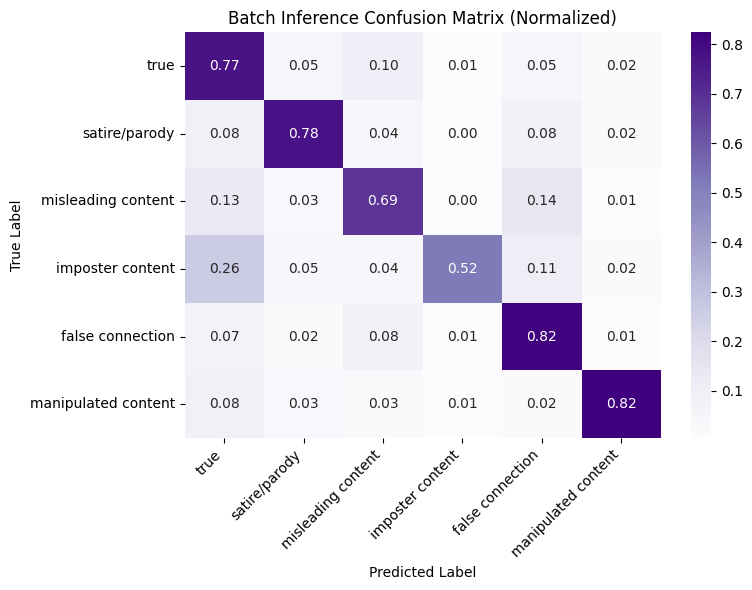

In [14]:

MODE='batch'
if MODE == 'batch':
    df = pd.read_csv(BATCH_TSV, sep='\t', dtype=str)
    text_col = 'clean_title' if 'clean_title' in df.columns else 'title'
    df[text_col] = df[text_col].fillna('')
    print(f'Original TSV loaded: {len(df):,} rows.')


    print("Scanning for missing or corrupted images...")
    df['_img_path'] = df['id'].apply(lambda img_id: find_image_path(str(img_id).strip(), BATCH_IMG_DIR))
    
    before_len = len(df)
    df = df[df['_img_path'].notna()].reset_index(drop=True)
    print(f'Filtered out {before_len - len(df):,} missing/corrupt images.')
    print(f'Running inference on the remaining {len(df):,} valid samples...\n')


    all_preds, all_conf = [], []

    for start in tqdm(range(0, len(df), BATCH_SIZE), desc='Predicting'):
        batch  = df.iloc[start : start + BATCH_SIZE]
        texts  = batch[text_col].tolist()
        

        images = [Image.open(p).convert('RGB') for p in batch['_img_path']]
        
        p, prb, c = predict(texts, images)
        all_preds.extend(p)
        all_conf.extend(c)


    results = df[['id', text_col]].copy()
    if '6_way_label' in df.columns:
        results['true_label'] = df['6_way_label'].apply(
            lambda x: CFG['class_names'][int(x)] if pd.notna(x) else 'unknown'
        )
    results['predicted'] = all_preds
    results.to_csv(SAVE_CSV, index=False)
    print(f'\n✓ Predictions saved to {SAVE_CSV}')

  
    if 'true_label' in results.columns:
        known = results[results['true_label'] != 'unknown']
        true_idx = [CFG['class_names'].index(l) for l in known['true_label']]
        pred_idx = [CFG['class_names'].index(l) for l in known['predicted']]

        print(f'\nAccuracy : {(known["true_label"] == known["predicted"]).mean():.4f}')
        print(f'Macro-F1 : {f1_score(true_idx, pred_idx, average="macro"):.4f}\n')
        print(classification_report(true_idx, pred_idx, target_names=CFG['class_names'], digits=4))
        
       
        cm = confusion_matrix(true_idx, pred_idx).astype(float)
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples',
                    xticklabels=CFG['class_names'], yticklabels=CFG['class_names'])
        plt.title('Batch Inference Confusion Matrix (Normalized)')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(CFG['out_dir'], 'batch_confusion_matrix.png'), dpi=150)
        plt.show()

In [17]:
import shutil
shutil.make_archive('/kaggle/working/inference_outputs', 'zip', '/kaggle/working')
print('inference_outputs.zip ready — download from Output tab')

✓ inference_outputs.zip ready — download from Output tab
